In [1]:
!pip install lime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss



df = pd.read_csv("email.csv")
df

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=67b5d8f02f0089bbeba8774d47ca99139a178c4f0106971ee0a39dbb174947cc
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...
...,...,...,...,...,...,...,...,...,...,...,...
90936,{T6N5-J2OX33MD-5258HBTN},01/19/2010 08:59:12,VEB0935,PC-3534,Edan.Ciaran.Larson@dtaa.com;Dominic.Howard.Mcc...,MacKensie.Mara.Grant@dtaa.com;Gibbs-Judah@rayt...,NaN,Valentine.Elton.Britt@dtaa.com,53447,0,southeastern 8 making convinced left ship sign...
90937,{R9D6-L8MY67GM-0955QJIJ},01/19/2010 08:59:13,KNB0022,PC-9873,Sybill.Grace.Mckay@dtaa.com,NaN,NaN,Keane.Nicholas.Blevins@dtaa.com,18457,0,maggie other cross entirety next stalls despit...
90938,{P9G8-X2MV82KF-4300EING},01/19/2010 08:59:14,AIM0627,PC-3297,Jana.Amanda.Dorsey@dtaa.com,NaN,NaN,Adam.Ishmael.Mcdaniel@dtaa.com,18960,0,played connections superior slightly guilty pr...
90939,{M4Y0-H1QZ60QT-5018JTSE},01/19/2010 08:59:18,ESJ0670,PC-2321,Ann.J.Potts@bellsouth.net,Sarah_Juarez@cox.net,NaN,Jennings-Eaton@hotmail.com,28752,0,represents called such theyre tree three long ...


## 1. Load and Preprocess Data

In [2]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Fill missing vals
df.fillna('', inplace=True)

In [3]:
# Label encoding for categorical columns
le = LabelEncoder()
for col in ['user', 'pc', 'to', 'cc', 'bcc', 'from']:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},2010-01-02 07:11:45,588,553,9581,8714,0,1236,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},2010-01-02 07:12:16,675,665,28388,0,0,1255,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},2010-01-02 07:13:00,588,553,29240,0,0,1237,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},2010-01-02 07:13:17,588,553,20079,0,0,1237,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},2010-01-02 07:13:28,675,665,4606,0,439,1255,17319,0,this kmh october holliswood number advised unu...


## 2. Exploratory Data Analysis (EDA)

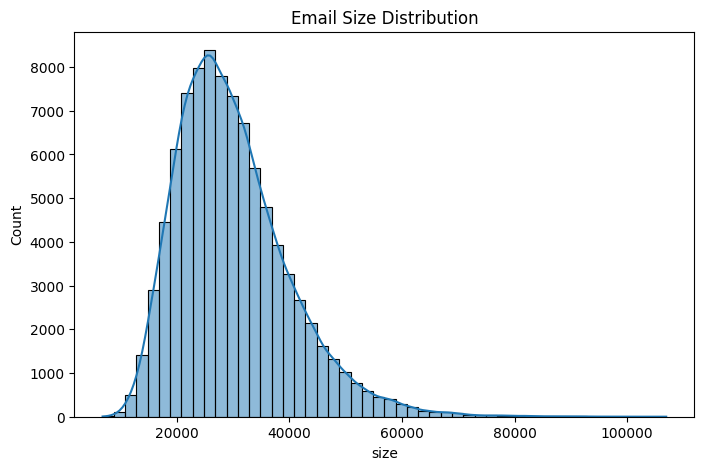

In [4]:
#size dist
plt.figure(figsize=(8,5))
sns.histplot(df['size'], bins=50, kde=True)
plt.title("Email Size Distribution")
plt.show()


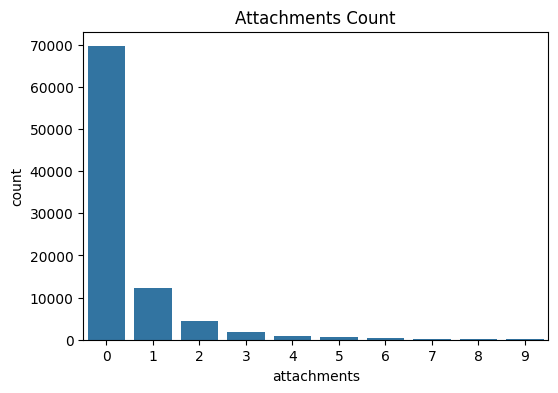

In [5]:
#Num ofattachments
plt.figure(figsize=(6,4))
sns.countplot(x='attachments', data=df)
plt.title("Attachments Count")
plt.show()


## 3. Generate Labels (Rule-Based)

In [6]:
# Feature Engineering from 'date'
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday
df['month'] = df['date'].dt.month
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

# feature selection
df.drop(columns=['date', 'to', 'cc', 'from'], inplace=True)


In [7]:
# Create a label based on 'bcc' and 'size' as suspicious
df['size'] = pd.to_numeric(df['size'], errors='coerce')
df['size'] = df['size'].fillna(0)
df['is_malicious'] = ((df['bcc'].astype(str).astype(int) > 0) & (df['size'] > 50000)).astype(int)

print(df['is_malicious'].value_counts())

is_malicious
0    90299
1      642
Name: count, dtype: int64


In [8]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

features = df.select_dtypes(include=['number', 'bool']).columns.tolist()
features.remove('is_malicious')

X = df[features]
y = df['is_malicious']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 4. isolation Model MOHAMED TAREK 202201058

In [10]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
model.fit(X_train)

y_pred = model.predict(X_test)
y_pred = [1 if val == -1 else 0 for val in y_pred]


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Benign", "Malicious"]))


[[24439  2642]
 [   45   157]]
              precision    recall  f1-score   support

      Benign       1.00      0.90      0.95     27081
   Malicious       0.06      0.78      0.10       202

    accuracy                           0.90     27283
   macro avg       0.53      0.84      0.53     27283
weighted avg       0.99      0.90      0.94     27283



In [13]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['Benign', 'Threat'],
    mode='classification'
)

def predict_proba_for_lime(X):
    pred = model.predict(X)
    pred = np.array([1 if p == -1 else 0 for p in pred])
    proba = np.zeros((len(pred), 2))
    proba[:, 0] = 1 - pred
    proba[:, 1] = pred
    return proba

i = 31
exp = explainer.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=predict_proba_for_lime
)

exp.show_in_notebook()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


# ***shap***

100%|===================| 27177/27283 [03:30<00:00]       

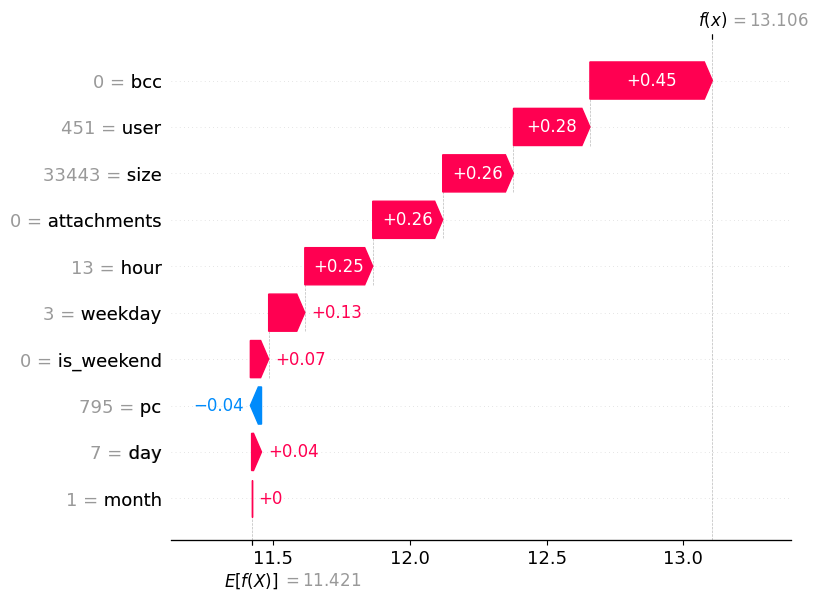

In [14]:
import shap

explainer_shap = shap.Explainer(model, X_train)
shap_values = explainer_shap(X_test)
shap.plots.waterfall(shap_values[0])

# ***# This explains one prediction. 'bcc' and 'user' increased the risk, while 'pc' slightly reduced it.***


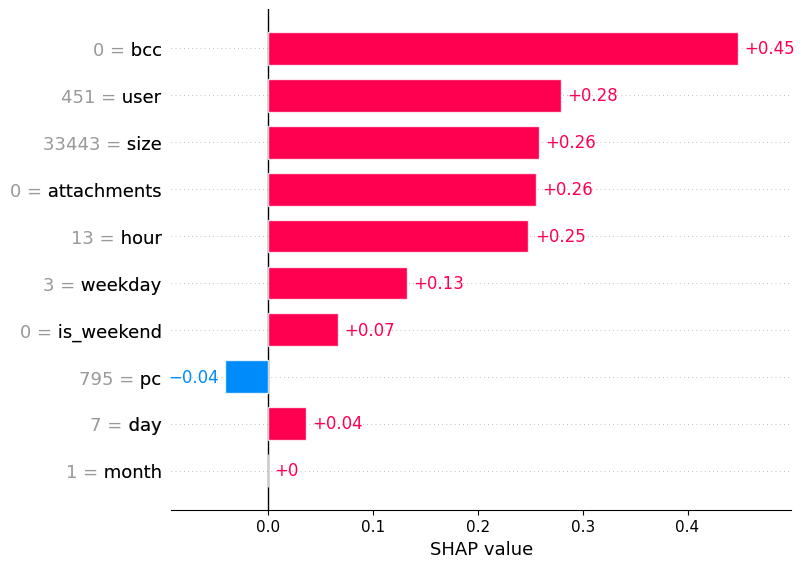

In [15]:
shap.plots.bar(shap_values[0])

# ***# On average, bcc, user, and attachments have the biggest impact on the model’s output.***


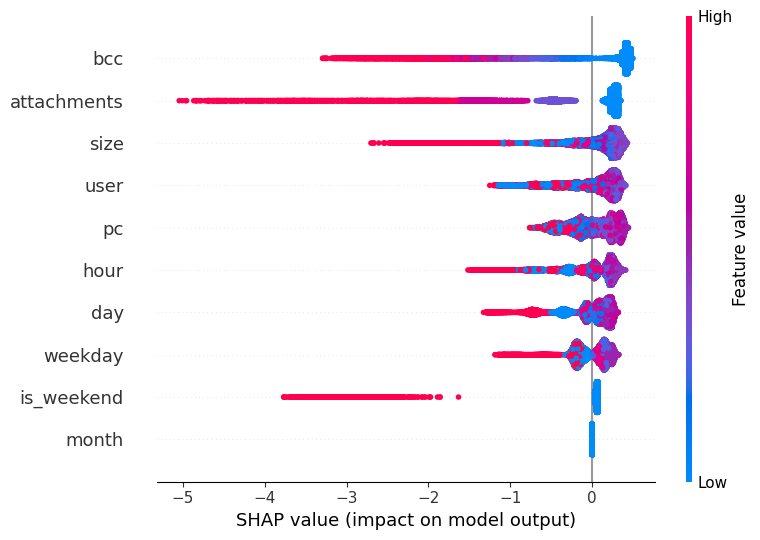

In [16]:
shap.summary_plot(shap_values, X_test)

## ***This plot shows how each feature impacts all predictions. 'bcc' and 'attachments' have the strongest and most consistent influence.***


# ***PFI***

In [30]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

y_pred_test = model.predict(X_test)
y_pred_test = [1 if val == -1 else 0 for val in y_pred_test]

perm_result = permutation_importance(
    model,
    X_test,
    y_pred_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

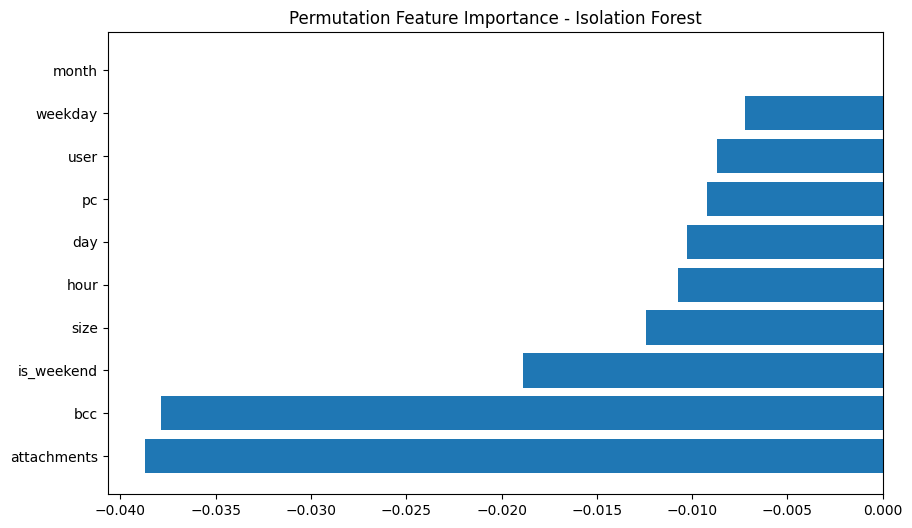

In [31]:
sorted_idx = perm_result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[sorted_idx], perm_result.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance - Isolation Forest")
plt.show()

# ***# 'Attachments' and 'bcc' are the top features, which makes sense based on our logic for detecting malicious emails.***


# ***GST***

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

y_surrogate = model.predict(X_train)
y_surrogate = [1 if val == -1 else 0 for val in y_surrogate]


surrogate = DecisionTreeClassifier(max_depth=3, random_state=42)
surrogate.fit(X_train, y_surrogate)

DecisionTreeClassifier(max_depth=3, random_state=42)

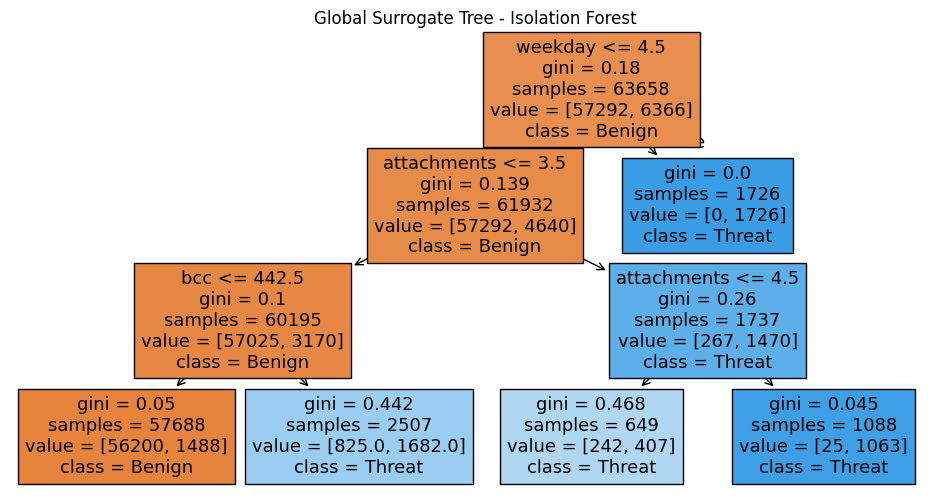

In [27]:
plt.figure(figsize=(12,6))
tree.plot_tree(
    surrogate,
    feature_names=X_train.columns,
    filled=True,
    class_names=["Benign", "Threat"]
)
plt.title("Global Surrogate Tree - Isolation Forest")
plt.show()

# *# The tree shows simple rules the model uses. High 'bcc' or many 'attachments' can lead to threat classification.*


# ***DONE MODEL 1***